# Matplotlib Animation Tutorial

### Katelyn Buechler

## Introduction

Animation is an especially important tool in data analysis. Despite this, many plotting tutorials online stop at just static charts. Even when tutorials are implemented for animated visualizations, they often use synthetic data such as sine waves building itself across a plot. Although those approaches do aid in teaching the overall mechanics, they don't do much to show why animation actually matters as a visualization choice!

With this in mind, this tutorial takes a different approach. Instead, we will be using real Billboard Hot 100 chart data from the year 2025 to display:

1. A **bar chart race** showing songs building chart longevity over the course of 2025.
2. A **three-song trajectory** showing five top songs moving up and down the Hot 100 week by week.


### Why animation here/course connections:

Here, animation is incredibly useful due to the fact the Billboard Hot 100 is inherently time based, each chart week a representation of a new moment in time of the year. With this, having visible motion can aid in showing how songs rise, fall, and compete over time. This connects to *Segel and Heer’s* discussion of animated transitions in narrative visualization. Rather than making a sudden jump from one chart state to another, the usage of animation can help viewers have a clear mental model of how things are changing. This use of motion supports orientation and continuity instead of simply making the chart look more exciting.

At the same time, one must remember that animation needs to be used carefully. With Tufte's critique of chartjunk, motion can easily become decoration if it doesn't properly serve the data. Alongside this, Cairo’s emphasis on truthful visualization still applies, therefore animation should try to clarify the visualization instead of exaggerating it. 

For that reason, this tutorial keeps the designs relatively simple, uses clear labels, and focuses on changes that are actually meaningful in the dataset. Animation is not always the best choice. If the goal is precise comparison, a static chart or small multiples may be clearer. But for this project, animation makes sense because the main story is about movement through time.

### Prerequisites

- Python 3 with `pandas`, `matplotlib`, `numpy`
- FFmpeg installed (`ffmpeg --version` should work in your terminal)
- ImageMagick installed (`magick --version`)

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

## Load the Hot 100 dataset

We'll use the Billboard Hot 100 dataset from the [UT Austin R for Data Science Billboard data repository](https://github.com/utdata/rwd-billboard-data). This dataset is especially useful for animation as each row already represents a song on the chart during a specific moment of time (week). 

The main variables we will be using are:

- `chart_week`: the date of the Billboard chart
- `current_week`: the song’s rank during that week
- `title`: the song title
- `performer`: the artist
- `wks_on_chart`: how many total weeks the song has been on the chart

First, we will load the dataset directly from its public CSV link.

In [2]:
data_url = "https://raw.githubusercontent.com/utdata/rwd-billboard-data/main/data-out/hot-100-current.csv"

hot100 = pd.read_csv(data_url, encoding="latin-1")

hot100.head()


,chart_week,current_week,title,performer,last_week,peak_pos,wks_on_chart
0,2022-01-01,1,All I Want For Christmas Is You,Mariah Carey,1.0,1,50
1,2022-01-01,2,Rockin' Around The Christmas Tree,Brenda Lee,2.0,2,44
2,2022-01-01,3,Jingle Bell Rock,Bobby Helms,4.0,3,41
3,2022-01-01,4,A Holly Jolly Christmas,Burl Ives,5.0,4,25
4,2022-01-01,5,Easy On Me,Adele,3.0,1,11


## Focus on 2025

Although the dataset spans many decades, we only want one year: with this, we'll be focusing on the most recent, being 2025.

We convert `chart_week` to a real date, then filter to **2025**.

Along with this, we also create a combined `song` column (title + artist) to use as a unique label.

In [3]:
hot100["chart_week"] = pd.to_datetime(hot100["chart_week"])

# keep only rows from 2025
hot100_2025 = hot100[hot100["chart_week"].dt.year == 2025].copy()

# then make one label that combines the song title and artist
hot100_2025["song"] = hot100_2025["title"] + " - " + hot100_2025["performer"]

# sort by the week and chart rank 
hot100_2025 = hot100_2025.sort_values(["chart_week", "current_week"])

hot100_2025.head()

,chart_week,current_week,title,performer,last_week,peak_pos,wks_on_chart,song
15700,2025-01-04,1,All I Want For Christmas Is You,Mariah Carey,1.0,1,71,All I Want For Christmas Is You - Mariah Carey
15701,2025-01-04,2,Rockin' Around The Christmas Tree,Brenda Lee,2.0,1,64,Rockin' Around The Christmas Tree - Brenda Lee
15702,2025-01-04,3,Last Christmas,Wham!,3.0,3,45,Last Christmas - Wham!
15703,2025-01-04,4,Jingle Bell Rock,Bobby Helms,4.0,3,61,Jingle Bell Rock - Bobby Helms
15704,2025-01-04,5,Santa Tell Me,Ariana Grande,9.0,5,29,Santa Tell Me - Ariana Grande


## A short overview of `matplotlib.animation`

In advance, I will give a short summary on the core of this tutorial: `FuncAnimation`.

In simplified form, it works like this:

```python
animation = FuncAnimation(fig, update_function, frames=frame_values, interval=250)
```

The main parts it has are:

- `fig`: the Matplotlib figure being animated
- `update_function`: a function that redraws the chart for one frame
- `frames`: the sequence of frame values to iterate over
- `interval`: delay between frames in milliseconds

Essentially, Matplotlib repeatedly calls the update function and passes one frame at a time!

This will be further elaborated more in depth later on, but it is good to understand the mechanics early to think about as we continue on. 

## Exploratory Data Analysis

Before animating, it helps to do a little exploratory analysis in advance!

First, we will summarize each song. For each song, we find its best rank, how many weeks it appeared in 2025, and how many total chart weeks were recorded for it in the dataset.

In [4]:
song_summary = hot100_2025.groupby("song").agg({
    "current_week": "min",
    "chart_week": "nunique",
    "wks_on_chart": "max"
}).reset_index()

song_summary = song_summary.rename(columns={
    "current_week": "best_rank",
    "chart_week": "weeks_present_in_2025",
    "wks_on_chart": "total_chart_weeks_recorded"
})

song_summary = song_summary.sort_values(
    ["weeks_present_in_2025", "best_rank"],
    ascending=[False, True]
)

song_summary.head(10)

,song,best_rank,weeks_present_in_2025,total_chart_weeks_recorded
435,Mutt - Leon Thomas,6,46,46
477,Ordinary - Alex Warren,1,45,45
712,Wildflower - Billie Eilish,29,44,72
160,Die With A Smile - Lady Gaga & Bruno Mars,1,42,60
402,Luther - Kendrick Lamar & SZA,1,42,46
250,Good News - Shaboozey,12,42,46
20,A Bar Song (Tipsy) - Shaboozey,2,41,77
390,Lose Control - Teddy Swims,4,41,112
496,Pink Pony Club - Chappell Roan,4,41,68
64,Beautiful Things - Benson Boone,8,41,89


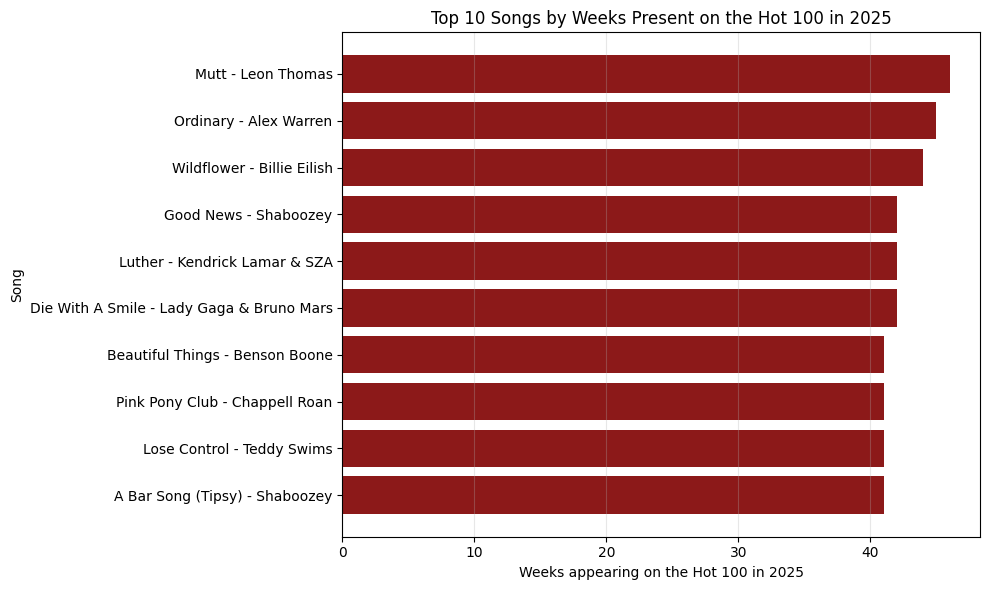

In [5]:
top_10_longevity = song_summary.head(10).sort_values("weeks_present_in_2025")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_10_longevity["song"], top_10_longevity["weeks_present_in_2025"], color="maroon", alpha=0.90)

ax.set_title("Top 10 Songs by Weeks Present on the Hot 100 in 2025")
ax.set_xlabel("Weeks appearing on the Hot 100 in 2025")
ax.set_ylabel("Song")

ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

## Prepare Data for the Bar Chart Race

A bar chart race is essentially just a sequence of horizontal bar charts drawn one after another, giving the effect of motion. Each frame shows the top 10 songs at that moment in time and the bars grow in tandem as songs accumulate more weeks on the chart! 

1. Look at all chart data up to the current week.
2. Find each song's running total of weeks on the chart in 2025.
3. Keep the top 10 songs for that moment.
4. Redraw the bar chart.

As mentioned before, the overall key idea is that the animation function (FuncAnimation) will keep redrawing the same figure with updated data.

In [6]:
race_df = hot100_2025[["chart_week", "song"]].copy()

race_df["weeks_in_2025_so_far"] = race_df.groupby("song").cumcount() + 1

race_df.head()

,chart_week,song,weeks_in_2025_so_far
15700,2025-01-04,All I Want For Christmas Is You - Mariah Carey,1
15701,2025-01-04,Rockin' Around The Christmas Tree - Brenda Lee,1
15702,2025-01-04,Last Christmas - Wham!,1
15703,2025-01-04,Jingle Bell Rock - Bobby Helms,1
15704,2025-01-04,Santa Tell Me - Ariana Grande,1


The column `weeks_in_2025_so_far` is the value that controls the length of each bar. As the animation moves through the year, this value increases whenever a song continues appearing on the Hot 100. Still, in order for us to keep the animation readable, we do not need to animate every song. With this, we'll instead track a smaller group of songs that share a similar chart longevity. The animation will still show only the top 10 songs in each frame!

In [7]:
top_songs = song_summary.head(15)["song"]

race_top = race_df[race_df["song"].isin(top_songs)].copy()

all_dates = sorted(race_top["chart_week"].unique())

print("Number of animation frames:", len(all_dates))
print("First frame:", all_dates[0])
print("Last frame:", all_dates[-1])

Number of animation frames: 52
First frame: 2025-01-04 00:00:00
Last frame: 2025-12-27 00:00:00


### Test single frame

Before you start your animation, you should always aim to first test your plot on a single frame. Essentially, once the animation starts running, debugging can become much harder. Checking beforehand to see if the chart looks wrong one frame is a great habit, as if it is off on one frame, the animation will likely look off overall. 

We write a small helper function that prepares the data for any given week, then draw it as a static chart to check it looks right!

In [8]:
def get_frame_data(current_date, top_n=10):
    current = race_top[race_top["chart_week"] <= current_date].copy()
    # sort by date so the most recent row for each song comes last
    current = current.sort_values("chart_week")
    # keep only the most recent row for each song
    current = current.groupby("song").tail(1)
    # keep the top songs for this frame
    current = current.sort_values("weeks_in_2025_so_far", ascending=False).head(top_n)
    current = current.sort_values("weeks_in_2025_so_far")

    return current

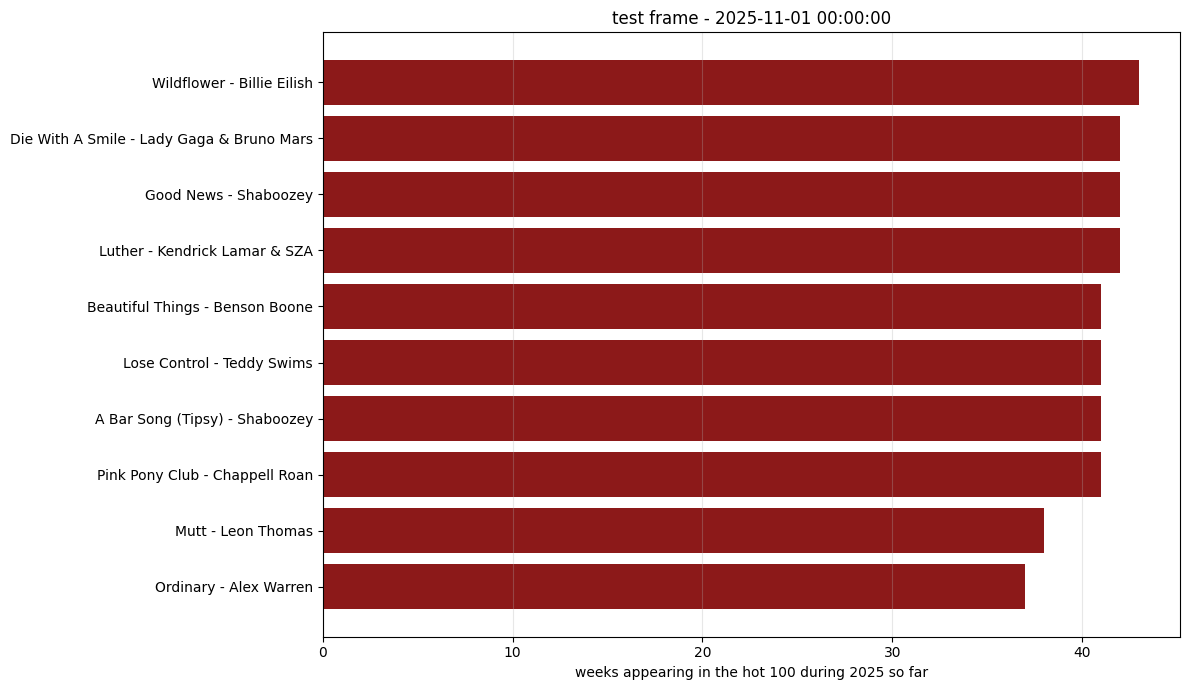

In [9]:
# pick one date to preview before making the full animation!
test_date = all_dates[43]
test_frame = get_frame_data(test_date)

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(
    test_frame["song"],
    test_frame["weeks_in_2025_so_far"],
    color="maroon", alpha=0.9)

ax.set_title(f"test frame - {test_date}")
ax.set_xlabel("weeks appearing in the hot 100 during 2025 so far")
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

### How `FuncAnimation` works (recap)

Matplotlib's `FuncAnimation` is a widely used standard tool for building animations. The core idea is simple: instead of drawing a chart once, you write a function that redraws the chart, and then `FuncAnimation` calls that function repeatedly!

```python
animation = FuncAnimation(
    fig,              # the figure to draw on
    update_function,  # called once per frame
    frames=...,       # what gets passed to update_function each call
    interval=250      # milliseconds between frames
)
```

The most important line inside the update function is `ax.clear()`. Without it, each new frame gets drawn *on top of* the previous one, you would essentially end up with a bunch of overlapping bars, so clearing the axes first and foremost ensures each frame starts fresh and ready! 

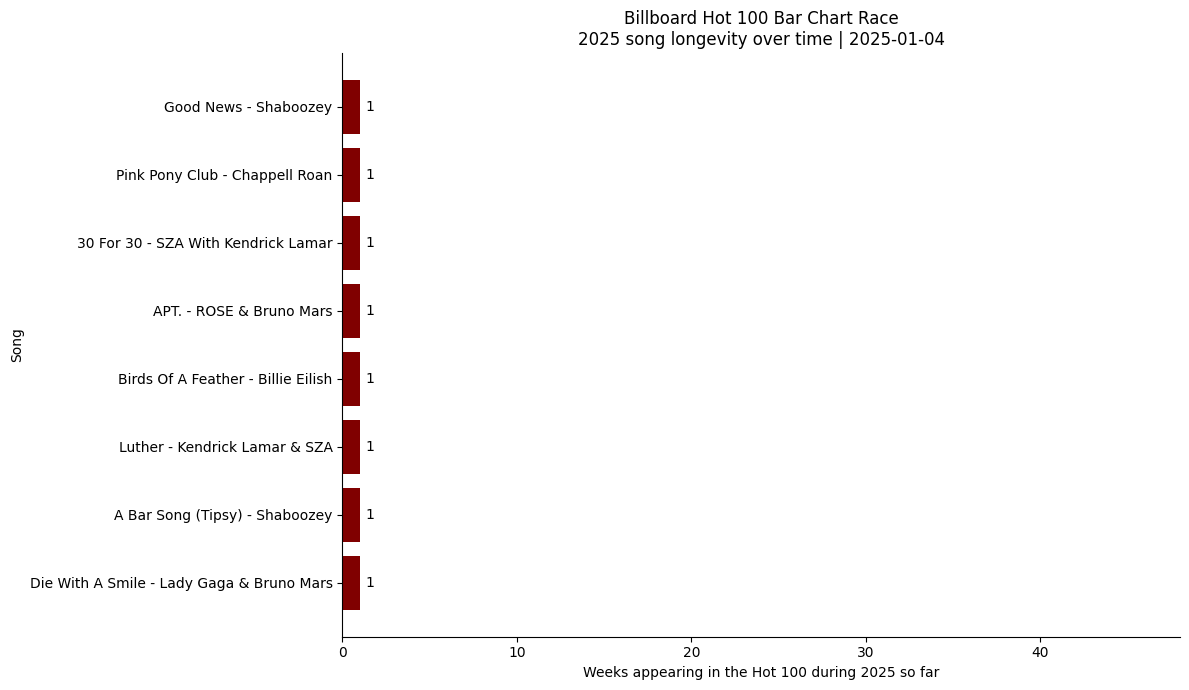

In [10]:
fig, ax = plt.subplots(figsize=(12, 7))

def draw_barchart(current_date):
    ax.clear()  

    current = race_top[race_top["chart_week"] <= current_date].copy()
    current = current.sort_values("chart_week")
    current = current.groupby("song").tail(1)
    current = current.sort_values("weeks_in_2025_so_far", ascending=False).head(10)
    current = current.sort_values("weeks_in_2025_so_far")

    ax.barh(current["song"], current["weeks_in_2025_so_far"], color="maroon")

    ax.set_xlim(0, race_top["weeks_in_2025_so_far"].max() + 2)
    ax.set_xlabel("Weeks appearing in the Hot 100 during 2025 so far")
    ax.set_ylabel("Song")
    ax.set_title(
        "Billboard Hot 100 Bar Chart Race\n"
        + "2025 song longevity over time | "
        + str(pd.to_datetime(current_date).date())
    )

    # Add a value label at the end of each bar
    for i in range(len(current)):
        value = current["weeks_in_2025_so_far"].iloc[i]
        ax.text(value + 0.3, i, str(value), va="center", fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()


bar_chart_race = FuncAnimation(
    fig,
    draw_barchart,
    frames=all_dates,   # funcanimation passes each date to draw_barchart one at a time
    interval=250,       # aka 4 fps
    repeat=False
)

HTML(bar_chart_race.to_jshtml())

### Saving the animation with FFmpeg or ImageMagick

Using the `.to_jshtml()` method above embeds the animation directly in the notebook, which is great for just doing exploration. But if you want to share the animation as a standalone file, there are two good options:

**FFmpeg converts to MP4**  
FFmpeg encodes your frames into a proper video file. It helps to record and stream audio and video. MP4 files are compact, high quality, and play in any video player or browser. With this in mind, FFmpeg is the best option when quality and file size matter!

**ImageMagick converts to GIF**  
On the other hand, ImageMagick converts your frames into an animated GIF. GIFs are limited to 256 colors and tend to be much larger than equivalent MP4s, but they have one big advantage: they embed directly in GitHub READMEs and Jupyter notebooks without needing a video player!

- **FFmpeg / MP4**
  - smaller file size
  - better color quality
  - widely supported by video players
  - does not usually auto-play directly inside a GitHub README

- **ImageMagick / GIF**
  - works well inline in a GitHub README
  - easy to view without a separate video player
  - often creates larger files
  - limited to 256 colors, so quality can look worse

When using `animation.save()`, Matplotlib handles the frame-by-frame rendering behind the scenes and hands the frames off to whichever tool you specify as the `writer`.

In [11]:
# Save as MP4 using FFmpeg (uncomment to run)
# bar_chart_race.save('hot100_2025_bar_chart_race.mp4', writer='ffmpeg', fps=4)

# Save as GIF using ImageMagick (uncomment to run)
# bar_chart_race.save('hot100_2025_bar_chart_race.gif', writer='imagemagick', fps=4)

#### **Note on fps:** The `fps` argument here controls playback speed. At `fps=4`, each chart week is slow enough to read the song names. Try `fps=8` if you want it to move faster, or `fps=2` to slow it down.

---
## Animation 2: Rank Trajectory for Three Songs

The bar chart race shows which songs stayed on the chart longest, but it doesn't capture *how* those songs moved individually. For that, a line chart that draws itself week by week is a better fit!

We'll track three songs side by side. As a lower rank number means a higher position on the chart, we will invert the y-axis so rank #1 appears at the top.

In [12]:
song_summary[["song", "best_rank", "weeks_present_in_2025"]].head(15)

,song,best_rank,weeks_present_in_2025
435,Mutt - Leon Thomas,6,46
477,Ordinary - Alex Warren,1,45
712,Wildflower - Billie Eilish,29,44
160,Die With A Smile - Lady Gaga & Bruno Mars,1,42
402,Luther - Kendrick Lamar & SZA,1,42
250,Good News - Shaboozey,12,42
20,A Bar Song (Tipsy) - Shaboozey,2,41
390,Lose Control - Teddy Swims,4,41
496,Pink Pony Club - Chappell Roan,4,41
64,Beautiful Things - Benson Boone,8,41


In [13]:
top_three_songs = [
    "Luther - Kendrick Lamar & SZA",
    "Die With A Smile - Lady Gaga & Bruno Mars",
    "A Bar Song (Tipsy) - Shaboozey"
]

multi_song_df = hot100_2025[hot100_2025["song"].isin(top_three_songs)].copy()

multi_song_df = multi_song_df.sort_values(["chart_week", "song"])

multi_song_df.head()

,chart_week,current_week,title,performer,last_week,peak_pos,wks_on_chart,song
15723,2025-01-04,24,A Bar Song (Tipsy),Shaboozey,13.0,1,37,A Bar Song (Tipsy) - Shaboozey
15716,2025-01-04,17,Die With A Smile,Lady Gaga & Bruno Mars,6.0,2,19,Die With A Smile - Lady Gaga & Bruno Mars
15726,2025-01-04,27,Luther,Kendrick Lamar & SZA,11.0,3,5,Luther - Kendrick Lamar & SZA
15801,2025-01-11,2,A Bar Song (Tipsy),Shaboozey,24.0,1,38,A Bar Song (Tipsy) - Shaboozey
15800,2025-01-11,1,Die With A Smile,Lady Gaga & Bruno Mars,17.0,1,20,Die With A Smile - Lady Gaga & Bruno Mars


### Building the trajectory animation

This animation works a little differently from the bar chart race. Instead of passing dates directly to the update function, we pass the frame indices and then we will use those in order to look up the corresponding date! Each frame adds one more week of data to the lines, so the trajectories build themselves from left to right across the chart. The dot at the end of each line marks the song's current position.

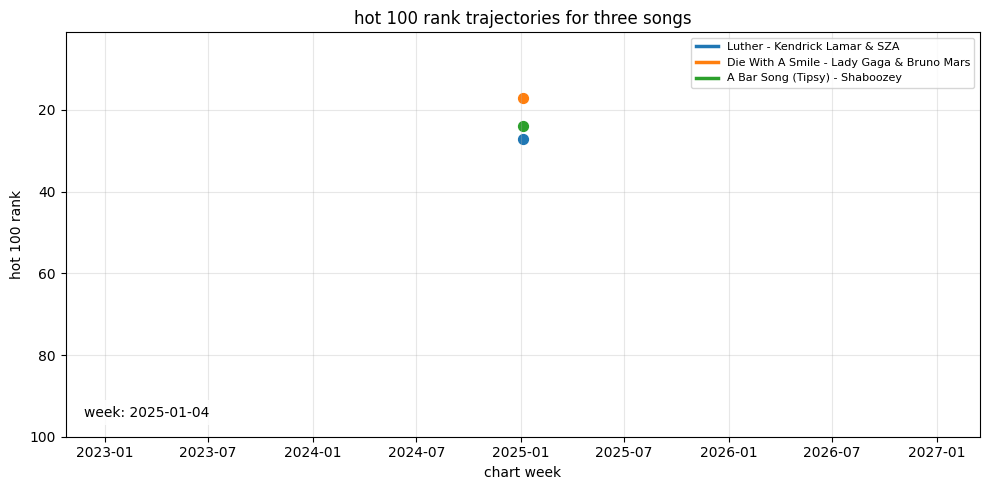

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

all_dates = sorted(multi_song_df["chart_week"].unique())

def draw_multi_song(current_date):
    ax.clear()

    # keep only data up to the current animation date
    current = multi_song_df[multi_song_df["chart_week"] <= current_date].copy()

    for song in top_three_songs:
        song_data = current[current["song"] == song].sort_values("chart_week")

        ax.plot(
            song_data["chart_week"],
            song_data["current_week"],
            linewidth=2.5,
            label=song
        )

        ax.scatter(
            song_data["chart_week"].iloc[-1],
            song_data["current_week"].iloc[-1],
            s=50
        )

    ax.set_ylim(100, 1)
    ax.set_title("hot 100 rank trajectories for three songs")
    ax.set_xlabel("chart week")
    ax.set_ylabel("hot 100 rank")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=8)

    ax.text(0.02, 0.05,
        "week: " + str(current_date.date()), transform=ax.transAxes,
        fontsize=10, bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"))

    plt.tight_layout()


multi_song_animation = FuncAnimation(
    fig,
    draw_multi_song,
    frames=all_dates,
    interval=250,
    repeat=False
)

display(HTML(multi_song_animation.to_jshtml()))

In [15]:
# Save as MP4 using FFmpeg (uncomment to run)
# multi_song_animation.save('hot100_2025_song_trajectory.mp4', writer='ffmpeg', fps=4)

# Save as GIF using ImageMagick (uncomment to run)
# multi_song_animation.save('hot100_2025_song_trajectory.gif', writer='imagemagick', fps=4)

---
## Final Note

In the end, animation overall works best when the viewer needs to follow a change over time! Both visualizations here are useful for animation due to the fact they are inherently temporal (songs rising, accumulating, etc.). In comparison, a static chart would either need to collapse that time axis or split into dozens of small multiples to tell the same story. That said, if precise comparison is what is being asked, a static chart is still clearer! 

One of the biggest lessons from this course: the best visualization is not the flashiest one, but instead the one that communicates and conveys the message most effectively!

## Thank you! 